# D² Normalization Comparison — Kersti's Hypstar data (L. Võrtsjärv)
**Testing 442.5 nm vs 620 nm vs 665 nm normalization for cyanobacteria detection at 552 nm**

Data: `Hypstar_radiometric_23-24.csv`  
Site: L. Võrtsjärv (Estonia) — cyanobacteria dominating nearly year-round  
Reference: Kersti Kangro (University of Tartu)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from phytospec.algorithms import compute_MALH, compute_CHL, compute_D2, lubac_phaeo_index
from phytospec import config as cfg
from scipy.stats import gaussian_kde

print('Imports OK')

Imports OK


## 1. Load and inspect Kersti's data
Her CSV has a different format from our RT1 data:
- First column: `Date` in `YYYYMMDD` format
- Remaining columns: non-integer wavelength values (e.g. 350.445, 350.909...)
- Range: ~350 to ~1100 nm

In [6]:
# ── Load data ─────────────────────────────────────────────────────────────────
DATA_PATH = cfg.DATA_RAW / "Hypstar_radiometric_23-24.csv"

# Read CSV as-is — do NOT add any columns yet
df_raw = pd.read_csv(DATA_PATH)

# Extract wavelength grid IMMEDIATELY (only 'Date' column is non-numeric here)
wl_cols = [c for c in df_raw.columns if c != 'Date']
wl      = np.array([float(c) for c in wl_cols])
RHOW    = df_raw[wl_cols].values

# NOW parse dates (adding columns after wl_cols is already fixed)
df = pd.DataFrame()
df['date']  = pd.to_datetime(df_raw['Date'].astype(str), format='%Y%m%d')
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year

print(f'Dataset: {len(df)} spectra')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Wavelength range: {wl[0]:.1f} – {wl[-1]:.1f} nm ({len(wl)} bands)')
print(f'Months present: {sorted(df["month"].unique())}')

Dataset: 129 spectra
Date range: 2023-05-07 to 2024-11-18
Wavelength range: 350.4 – 1099.8 nm (1536 bands)
Months present: [np.int32(3), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11)]


## 2. Implement D² function
Self-contained implementation (no phytospec dependency) so Kersti can also run this notebook.

D² is the second derivative of normalized reflectance:
$$D^2\rho_w(\lambda) = \frac{\rho_w(\lambda+\Delta) - 2\rho_w(\lambda) + \rho_w(\lambda-\Delta)}{\Delta^2}$$
applied to $\rho_w / \rho_w(\lambda_{norm})$ with 5-point running average smoothing.

In [7]:
def smooth_5pt(y):
    """5-point running average (Lubac et al. 2008)"""
    out = np.full_like(y, np.nan)
    for i in range(2, len(y) - 2):
        out[i] = np.mean(y[i-2:i+3])
    return out

def compute_D2(rhow, wl, norm_wl=None, delta=None, n_smooth=2):
    """
    Compute second derivative of normalized reflectance.

    Parameters
    ----------
    rhow    : array of reflectance values
    wl      : array of wavelengths (same length as rhow)
    norm_wl : normalization wavelength in nm. None = use index 35 (Lubac default).
    delta   : wavelength step in nm. If None, estimated from wl spacing.
    n_smooth: number of smoothing passes (default 2)

    Returns
    -------
    d2 : array of D² values (same length as rhow)
    """
    rhow = np.array(rhow, dtype=float)

    # Normalization
    if norm_wl is None:
        norm_idx = 35  # 442.5 nm for PANTHYR grid
    else:
        norm_idx = int(np.argmin(np.abs(wl - norm_wl)))

    norm_val = rhow[norm_idx]
    if norm_val == 0 or np.isnan(norm_val):
        return np.full_like(rhow, np.nan)

    rn = rhow / norm_val

    # Smoothing
    for _ in range(n_smooth):
        rn = smooth_5pt(rn)

    # Delta (wavelength step) — use median spacing if not provided
    if delta is None:
        delta = float(np.median(np.diff(wl)))

    # Second derivative
    d2 = np.full_like(rn, np.nan)
    for i in range(1, len(rn) - 1):
        if not (np.isnan(rn[i-1]) or np.isnan(rn[i]) or np.isnan(rn[i+1])):
            d2[i] = (rn[i+1] - 2*rn[i] + rn[i-1]) / (delta**2)

    return d2

print('D² function defined')
print(f'Median wavelength spacing in Kersti data: {np.median(np.diff(wl)):.3f} nm')

D² function defined
Median wavelength spacing in Kersti data: 0.491 nm


## 3. Compute D² under three normalizations
- **None / 442.5 nm** — Lubac et al. (2008) convention (index 35 on PANTHYR grid; nearest on Hypstar grid)
- **620 nm** — colleague's R implementation
- **665 nm** — supervisor's suggestion (chl-a red absorption peak, absorbs equally in all phytoplankton)

In [8]:
N   = len(df)
NWL = len(wl)

D2_442 = np.full((N, NWL), np.nan)
D2_620 = np.full((N, NWL), np.nan)
D2_665 = np.full((N, NWL), np.nan)

# Find nearest wavelength to 442.5 nm in Hypstar grid
idx_442 = int(np.argmin(np.abs(wl - 442.5)))
print(f'442.5 nm → using {wl[idx_442]:.2f} nm (index {idx_442})')

for i in range(N):
    rhow_i = RHOW[i, :]
    if np.sum(~np.isnan(rhow_i)) < 50:
        continue
    D2_442[i, :] = compute_D2(rhow_i, wl, norm_wl=442.5)
    D2_620[i, :] = compute_D2(rhow_i, wl, norm_wl=620.0)
    D2_665[i, :] = compute_D2(rhow_i, wl, norm_wl=665.0)

print('D² computed for all three normalizations')

442.5 nm → using 442.65 nm (index 196)
D² computed for all three normalizations


## 4. Extract D² at 552 nm (cyanobacteria detection wavelength)

In [9]:
idx_552 = int(np.argmin(np.abs(wl - 552.0)))
print(f'Detection wavelength: {wl[idx_552]:.2f} nm (index {idx_552})')

df['D2_552_442'] = D2_442[:, idx_552]
df['D2_552_620'] = D2_620[:, idx_552]
df['D2_552_665'] = D2_665[:, idx_552]

Detection wavelength: 552.14 nm (index 423)


## 5. Plot — Mean D² spectra by month (500–650 nm)
Grouped by month to show seasonal variation. Cyanobacteria expected year-round at L. Võrtsjärv.

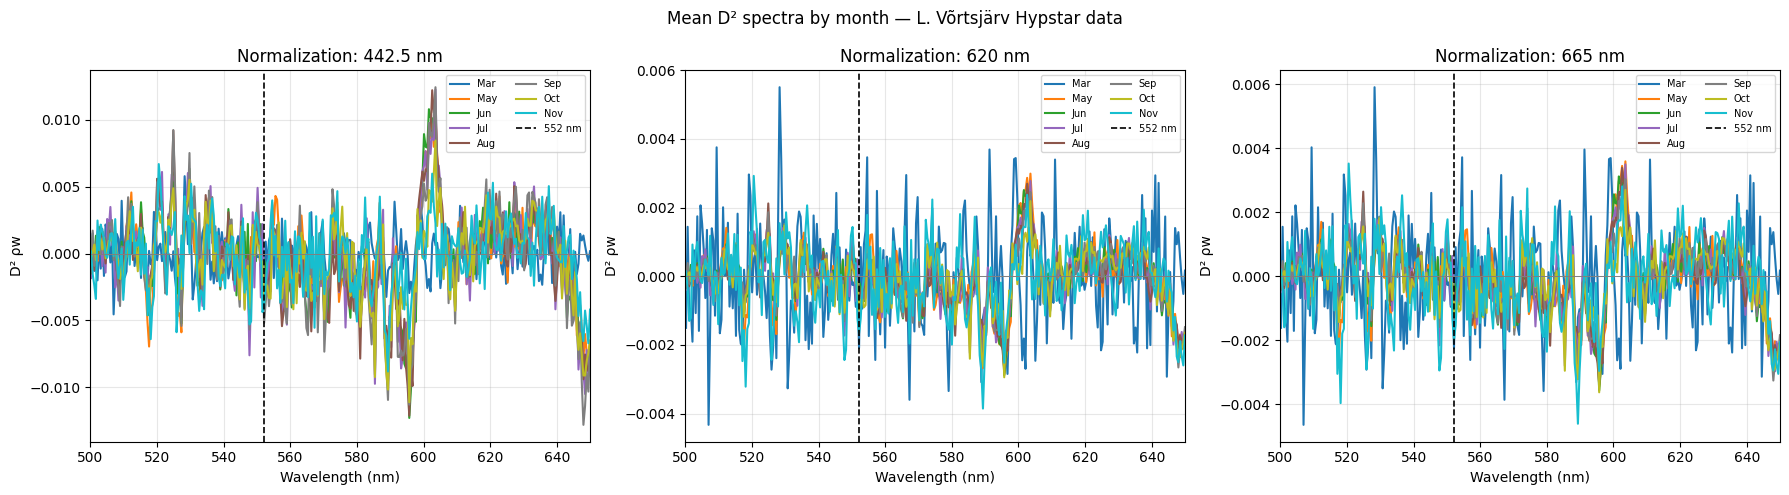

In [10]:
# Focus on 500-650 nm window
mask_wl = (wl >= 500) & (wl <= 650)
wl_plot = wl[mask_wl]

norm_labels = ['442.5 nm', '620 nm', '665 nm']
D2_list     = [D2_442[:, mask_wl], D2_620[:, mask_wl], D2_665[:, mask_wl]]

months_present = sorted(df['month'].unique())
cmap = plt.cm.tab10
colors = {m: cmap(i / max(len(months_present)-1, 1)) for i, m in enumerate(months_present)}
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, D2_w, norm_label in zip(axes, D2_list, norm_labels):
    for m in months_present:
        mask_m = df['month'] == m
        mean_d2 = np.nanmean(D2_w[mask_m, :], axis=0)
        ax.plot(wl_plot, mean_d2, color=colors[m],
                label=month_names[m], linewidth=1.5)

    ax.axvline(552, color='black', linestyle='--', linewidth=1.2, label='552 nm')
    ax.axhline(0,   color='gray',  linewidth=0.7)
    ax.set_xlim(500, 650)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('D² ρw')
    ax.set_title(f'Normalization: {norm_label}')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

fig.suptitle('Mean D² spectra by month — L. Võrtsjärv Hypstar data', fontsize=12)
plt.tight_layout()
plt.savefig('kersti_d2_spectra_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Plot — Time series of D² at 552 nm under all three normalizations

C:\Users\gvillegas\AppData\Local\Temp\ipykernel_50200\1577101346.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


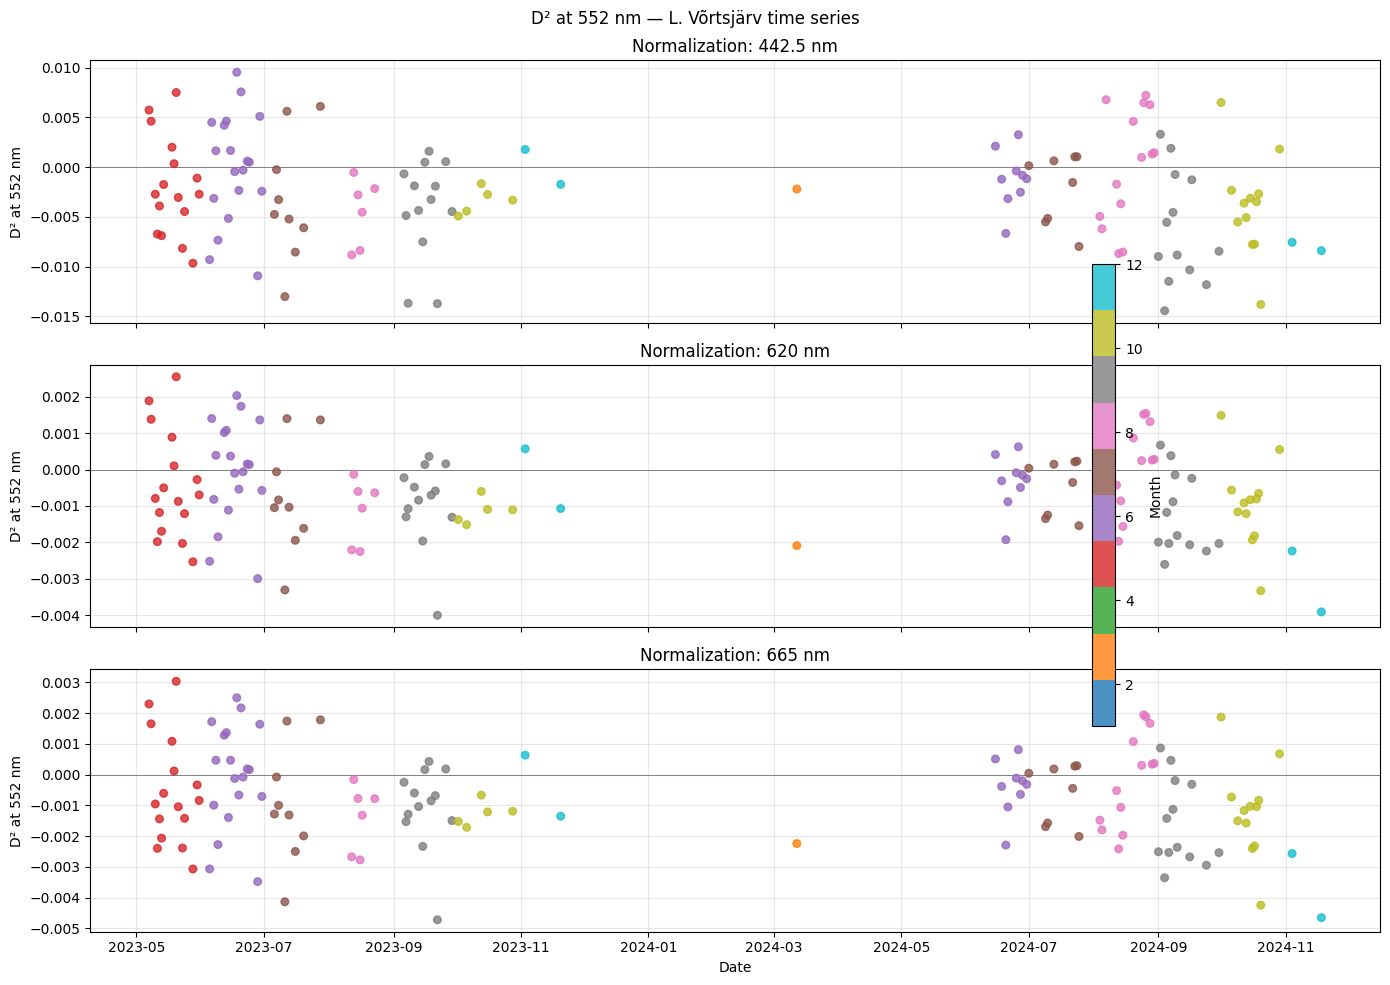

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, col, norm_label in [
    (axes[0], 'D2_552_442', '442.5 nm'),
    (axes[1], 'D2_552_620', '620 nm'),
    (axes[2], 'D2_552_665', '665 nm'),
]:
    sc = ax.scatter(df['date'], df[col],
                    c=df['month'], cmap='tab10',
                    vmin=1, vmax=12,
                    s=30, alpha=0.8, zorder=3)
    ax.axhline(0, color='gray', linewidth=0.7)
    ax.set_ylabel('D² at 552 nm')
    ax.set_title(f'Normalization: {norm_label}')
    ax.grid(True, alpha=0.3)

plt.colorbar(sc, ax=axes, label='Month', shrink=0.6)
axes[2].set_xlabel('Date')
fig.suptitle('D² at 552 nm — L. Võrtsjärv time series', fontsize=12)
plt.tight_layout()
plt.savefig('kersti_d2_552_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Plot — Raw RHOW spectra (reproduce Kersti's figure)
Grouped by month to verify data loaded correctly.

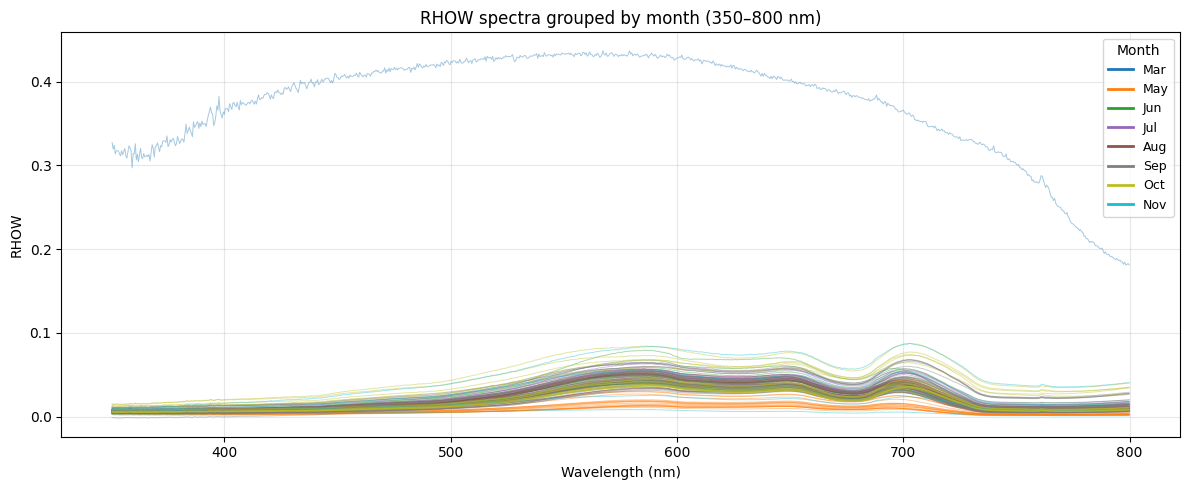

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

mask_vis = (wl >= 350) & (wl <= 800)

for m in months_present:
    mask_m = (df['month'] == m).values
    for i in np.where(mask_m)[0]:
        ax.plot(wl[mask_vis], RHOW[i, mask_vis],
                color=colors[m], alpha=0.4, linewidth=0.7)

# Legend proxies
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color=colors[m], linewidth=2, label=month_names[m])
           for m in months_present]
ax.legend(handles=handles, fontsize=9, title='Month')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('RHOW')
ax.set_title('RHOW spectra grouped by month (350–800 nm)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kersti_rhow_spectra.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Quantitative comparison — distribution statistics
Since cyanobacteria dominate year-round at L. Võrtsjärv, we compare summer peak months (Jun–Aug) vs winter/spring months (Jan–Mar) as a proxy for high vs low Cy biomass.

In [13]:
# Adjust these month ranges based on Kersti's in situ data if available
mask_cyano = df['month'].isin([6, 7, 8])    # summer bloom peak
mask_other = df['month'].isin([1, 2, 3])    # low Cy reference

print(f'Summer (Jun–Aug) spectra : {mask_cyano.sum()}')
print(f'Winter (Jan–Mar) spectra : {mask_other.sum()}')
print()

print('='*65)
print('D² at 552 nm — population statistics')
print('='*65)

for norm_label, col in [
    ('442.5 nm', 'D2_552_442'),
    ('620 nm',   'D2_552_620'),
    ('665 nm',   'D2_552_665'),
]:
    print(f'\nNormalization: {norm_label}')
    print(f'{"Population":<25} {"N":>5} {"Mean":>12} {"Std":>12}')
    print('-'*57)
    for label, mask in [
        ('Summer (cyano peak)', mask_cyano),
        ('Winter (low cyano)',  mask_other),
    ]:
        vals = df.loc[mask, col].dropna()
        print(f'{label:<25} {len(vals):>5} {vals.mean():>12.6f} {vals.std():>12.6f}')

    # Separation ratio
    cy = df.loc[mask_cyano, col].dropna()
    ot = df.loc[mask_other,  col].dropna()
    if len(cy) > 1 and len(ot) > 1:
        pooled_std = np.sqrt((cy.std()**2 + ot.std()**2) / 2)
        sep = abs(cy.mean() - ot.mean()) / pooled_std if pooled_std > 0 else np.nan
        print(f'  Separation ratio: {sep:.2f}')

Summer (Jun–Aug) spectra : 65
Winter (Jan–Mar) spectra : 1

D² at 552 nm — population statistics

Normalization: 442.5 nm
Population                    N         Mean          Std
---------------------------------------------------------
Summer (cyano peak)          65    -0.001299     0.005104
Winter (low cyano)            1    -0.002198          nan

Normalization: 620 nm
Population                    N         Mean          Std
---------------------------------------------------------
Summer (cyano peak)          65    -0.000334     0.001220
Winter (low cyano)            1    -0.002091          nan

Normalization: 665 nm
Population                    N         Mean          Std
---------------------------------------------------------
Summer (cyano peak)          65    -0.000408     0.001510
Winter (low cyano)            1    -0.002245          nan


## 9. Plot — Distribution comparison at 552 nm (all three normalizations)

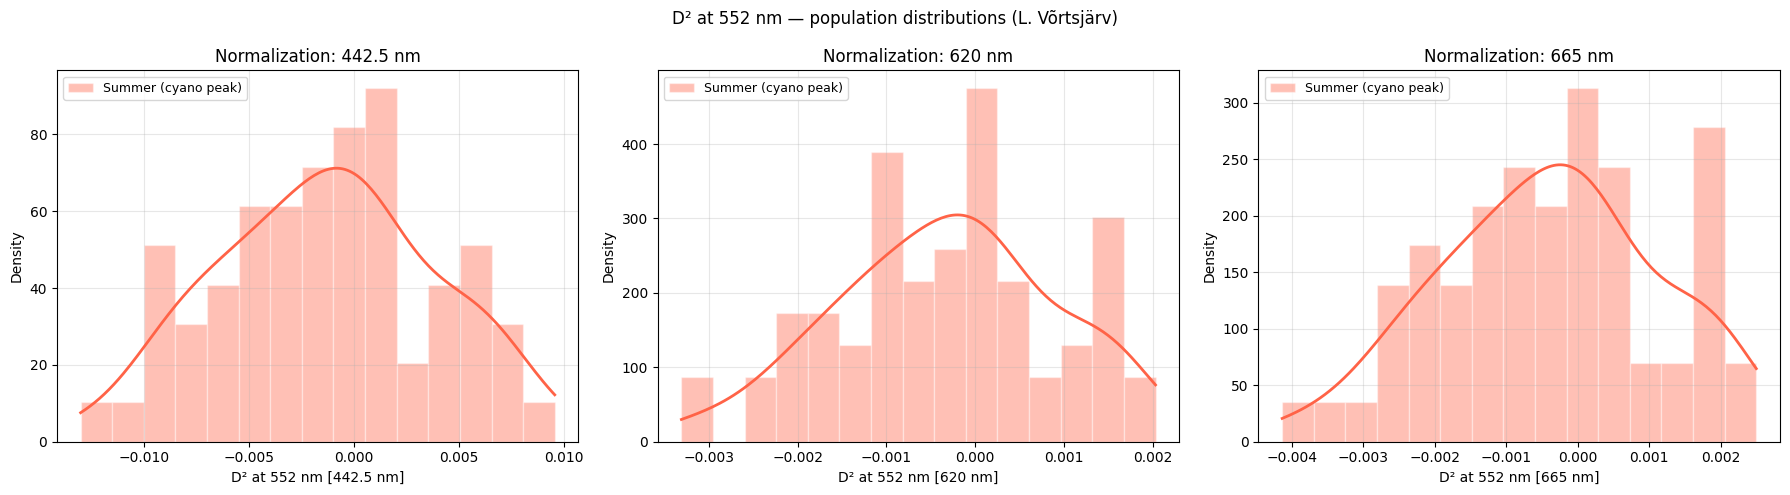

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, norm_label in [
    (axes[0], 'D2_552_442', '442.5 nm'),
    (axes[1], 'D2_552_620', '620 nm'),
    (axes[2], 'D2_552_665', '665 nm'),
]:
    for label, mask, color in [
        ('Summer (cyano peak)', mask_cyano, 'tomato'),
        ('Winter (low cyano)',  mask_other, 'steelblue'),
    ]:
        vals = df.loc[mask, col].dropna().values
        if len(vals) < 2:
            continue
        ax.hist(vals, bins=15, color=color, alpha=0.4,
                density=True, edgecolor='white', label=label)
        try:
            kde  = gaussian_kde(vals)
            xs   = np.linspace(vals.min(), vals.max(), 200)
            ax.plot(xs, kde(xs), color=color, linewidth=2)
        except Exception:
            pass

    ax.axhline(0, color='gray', linewidth=0.7)
    ax.set_xlabel(f'D² at 552 nm [{norm_label}]')
    ax.set_ylabel('Density')
    ax.set_title(f'Normalization: {norm_label}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('D² at 552 nm — population distributions (L. Võrtsjärv)', fontsize=12)
plt.tight_layout()
plt.savefig('kersti_d2_552_distributions.png', dpi=150, bbox_inches='tight')
plt.show()